# INTRODUCTION TO NEURAL NETWORKS AND PYTORCH

## Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
from torchsummary import summary
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import torch.nn.functional as F

## Computation tracking in PyTorch



In [ ]:
x = np.array(2.5)

In [ ]:
y = x**2 + x
y

8.75

Let's go back to our original vector `x`, but this time, we define it as a PyTorch tensor so that we can benefit from computation tracking:

In [ ]:
x = torch.tensor(2.5)
x

tensor(2.5000)

- By default, computations are not tracked and gradients can't be computed w.r.t `x`.
- But `tensor.torch()` accepts a parameter called `requires_grad=False`.
- If set to `True`, it tells PyTorch to keep track of all computations involving that tensor:

In [ ]:
x = torch.tensor(2.5, requires_grad=True)
x

tensor(2.5000, requires_grad=True)

Now if we do some computations using `x`:

In [ ]:
y = x**2 + x
y

tensor(8.7500, grad_fn=<AddBackward0>)

Note `grad_fn=<AddBackward0>` appearing in the output of the above cell. It's actually saying that the last operation that PyTorch observed and added to the history was an addition operation.

## Gradient computation

The process of using the chain rule in a backward manner (from the last computation back to its root at the variable) is called **back-propagation**. For now, let's learn how we make PyTorch compute the gradient for us using back-propagation.

PyTorch provides a `.backward()` method on every tensor that takes part in gradient computation.

Here, the final computation is stored in `y`, so we do chain rule starting from `y` all the way back to `x` using `.backward()`, to compute `dy/dx`:

In [ ]:
y.backward()

To confirm our results, here is the true value of the derivative:

$$\frac{dy}{dx} = 2x+1 = 2(2.5) + 1 = 6$$

Let's see if that's what we get using PyTorch:

In [ ]:
x.grad

tensor(6.)

### How does this help?

Well, what we just saw enables us to **do gradient descent without worrying about the structure of our model**, since we no longer need to compute the derivative ourselves.

- To get a clearer picture, recall that in GD or SGD, we need **the gradient of the loss function** to adjust the weights.

- What is the loss function? Is it anything other than a series of elementary computations performed on the weight parameters (along with some constant data points)?

- So if we track computations that involve the weights all the way to the loss function, we can compute the gradient of the loss function using back-propagation w.r.t to the weights (just like the example above)!

Recollecting GD function,

```python
w = np.array(w0)

g = 2 * (x * (w * x - y)).mean()
dw = alpha * g
w -= dw
```

If we now define `w` using PyTorch tensors, we can use `.backward()` on our loss function to compute the derivative w.r.t to `w`:

```python
w = torch.tensor(w0, requires_grad=True)

mse = ((x * w - y)**2).mean()
mse.backward()

with torch.no_grad():
    g = w.grad
    dw = alpha * g
    w -= dw

w.grad.zero_()
```

We'll see a lot more on this later!

## Training of Neural Networks

- Until now, we have seen how to do a forward pass
- But how does that fit into the training process?
- Here is the summary of steps that training of neural network needs
    1. Model Architecture Design (number of layers and nodes etc)
    2. Weight and Bias Initialization
    3. Forward Propagation
    4. Loss Computation
    5. Backward Propagation (Backpropagation)
    6. Parameter Updates
    7. Validation and Testing
    8. Hyperparameter Optimization


## Activity
### Back Propagation



Let's look at this example:
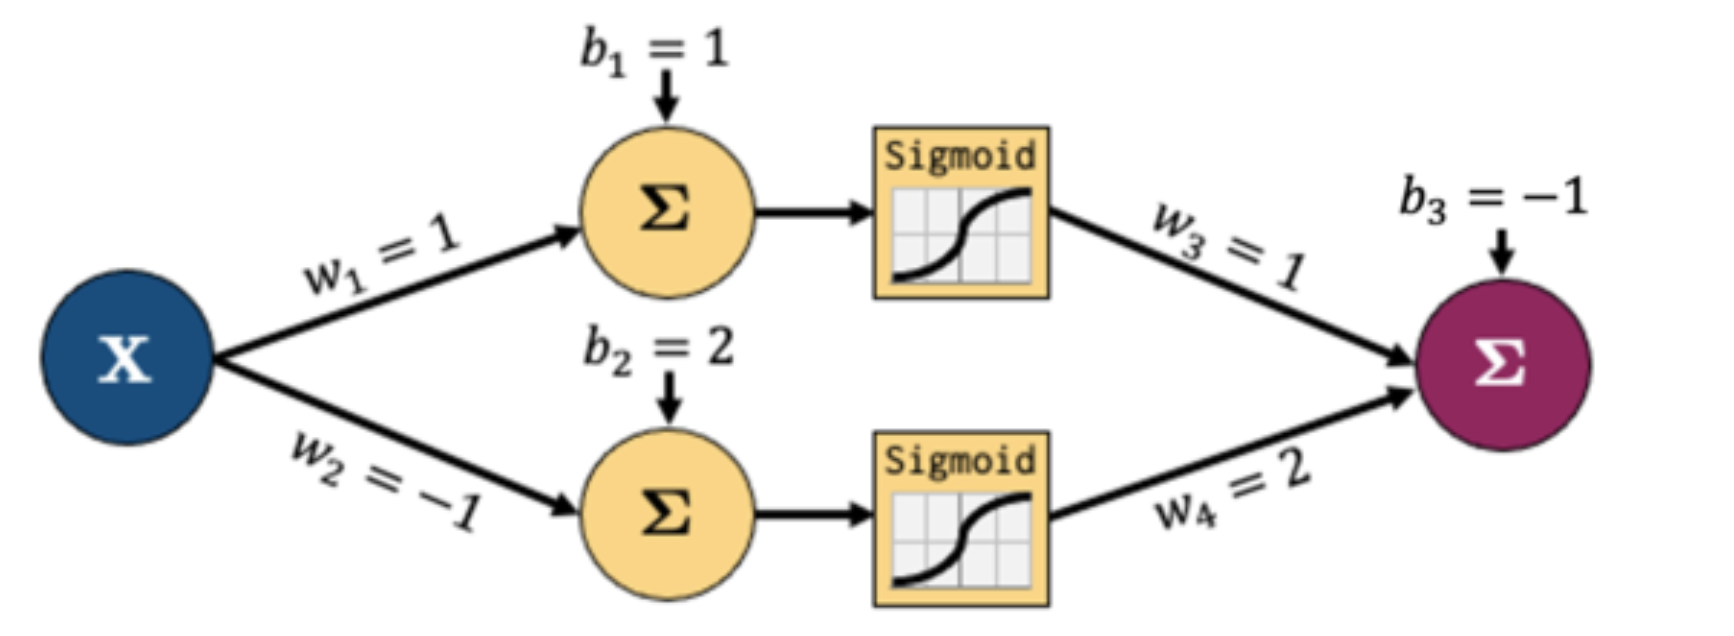

Let the loss $L$ be the average MSE loss, feed one data point `(x, y)` = `(1, 3)` to the model, and do the following:

- forward pass
- loss computation
- backward pass

Here, by backward pass, we mean compute the derivatives of the loss with respect to all the weights and biases.

You should get something like this:

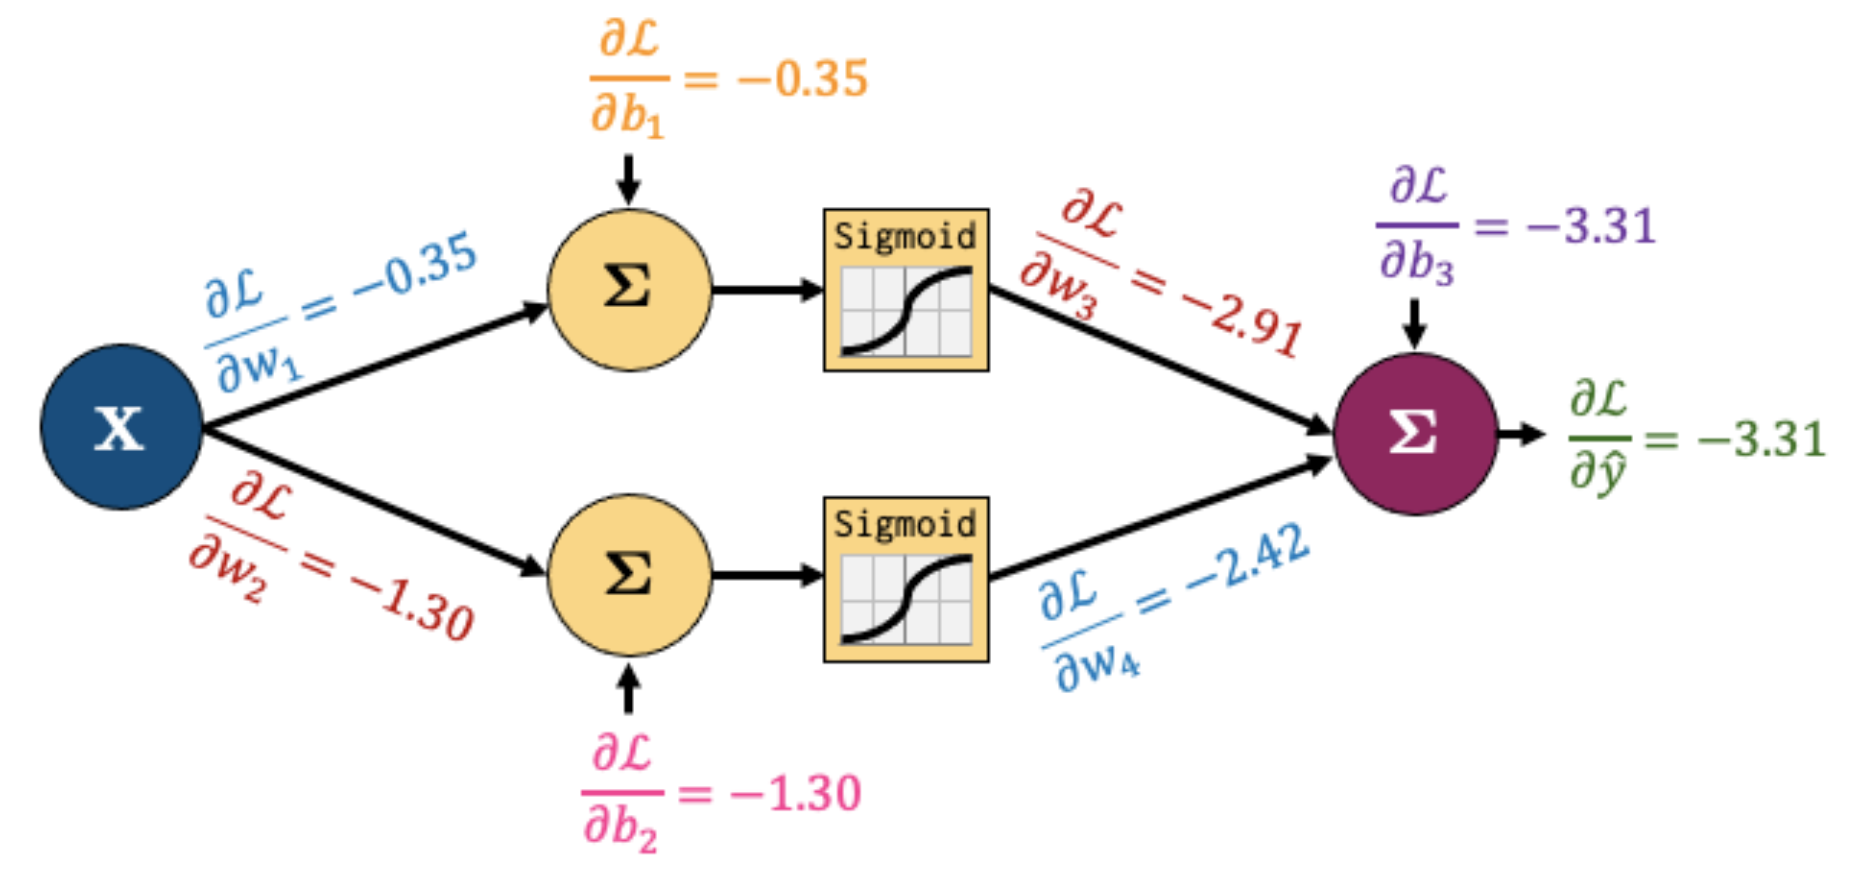

#### Why do we need all these derivatives?

These are needed so that the gradient of the loss function can be computed at $i$-th iteration, and weights can then be updated for the next iteration!

This is, in most basic terms, needed so that GD can be used

### A note on GD, SGD and Mini-batch SGD

- We remember GD and SGD from our first few lectures
- We saw that both GD and SGD have their pros and cons
- GD gives us more accurate solution but is slow and computationally heavy
- SGD, on the other hand, offers okayish results with much less computational effort
- There is also a middle ground - called **mini batch SGD**
- In mini-batch SGD, we process small batches of data points. Each batch is of a particular size that we can mention

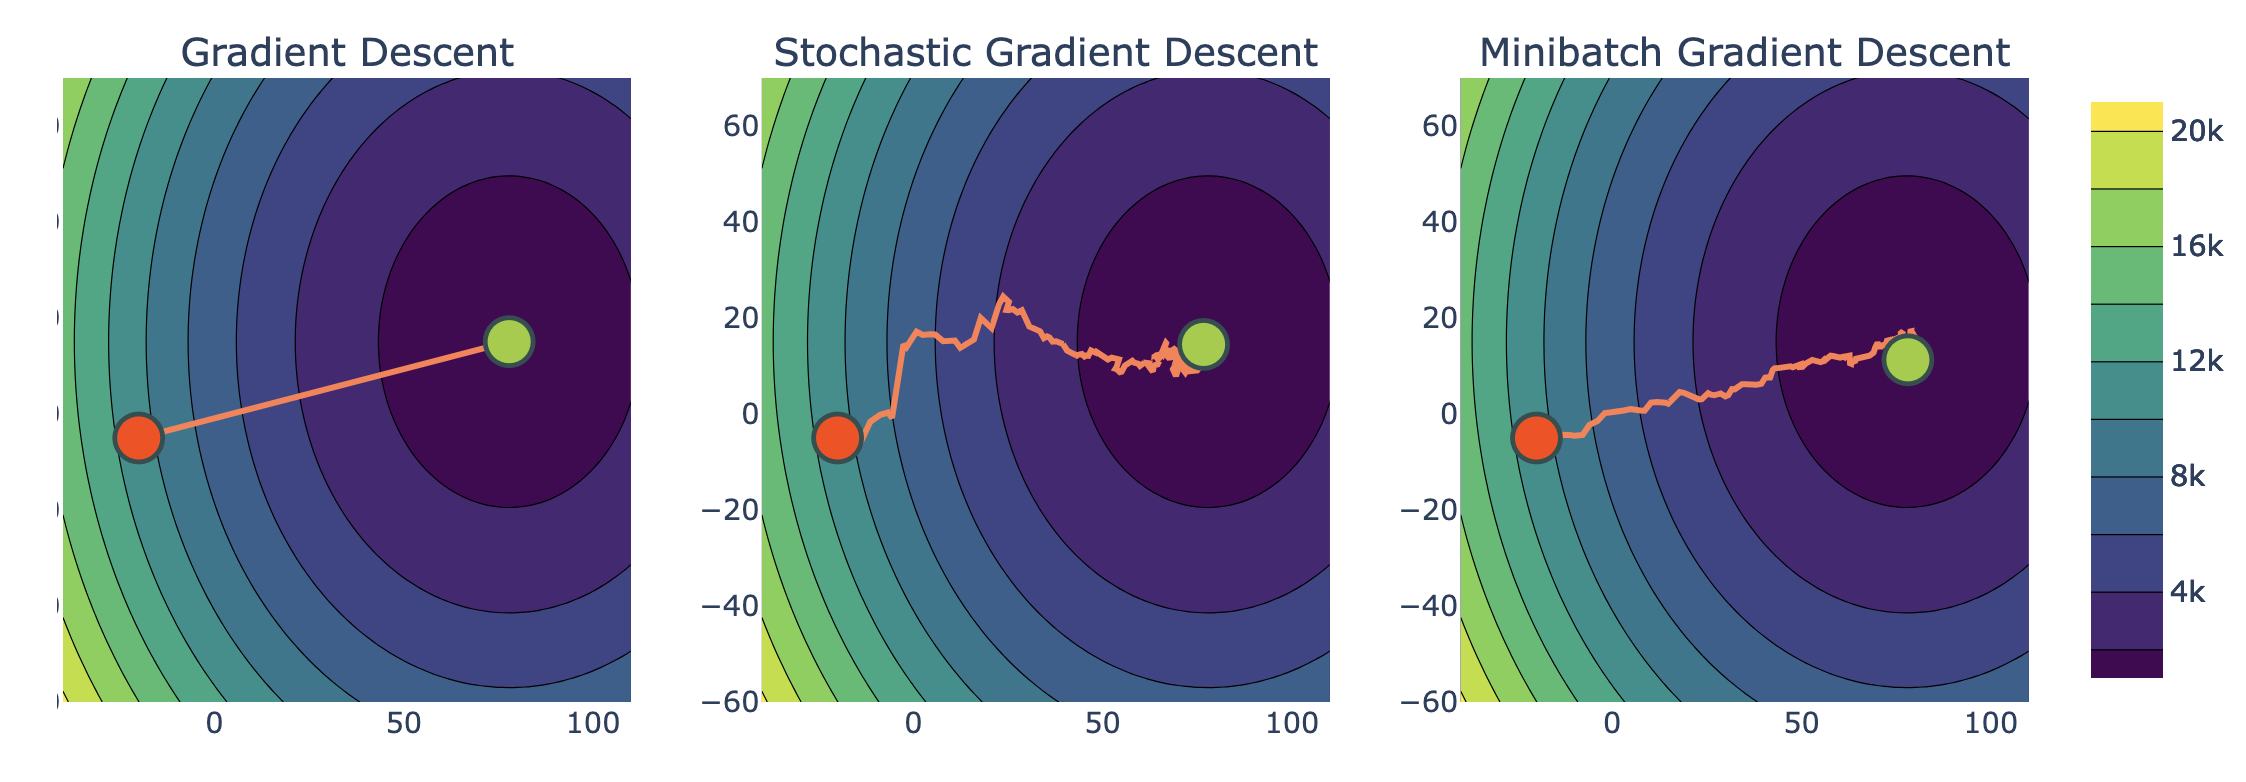

For one of the linear regression examples with 801 data points, we got the following comparisons

|Method|Intercept|Slope|Iterations|Data Per Iteration|Number of computations|
|---|---|---|---|---|---|
|sklearn|77.86|15.07|-|-|-|
|GD|77.85|15.07|466|801|373,266|
|SGD|76.33|11.26|300|1|300|
|MGD|75.60|15.09|300|10|3000|

#### Terminology

Assume we have a dataset of $n$ observations (also known as _rows, samples, examples, data points, or points_)

There are three terms you need to know when it comes to gradient descent:

- **Iteration**: each time you update model weights

- **Batch**: a subset of data used in an iteration

- **Epoch**: One full pass through the dataset to look at all $n$ observations

Let's put those definitions in context:
- In **GD**, each iteration involves computing the gradient over all examples, so

$$1 \: \text{iteration} = 1 \: \text{epoch}$$

- In **SGD**, each iteration involves one data point, so

$$n \text{ iterations} = 1 \: \text{epoch}$$

- In **MGD**, each iteration involves a batch of data, so

$$
\begin{align}
\frac{\text{iterations}}{\text{epochs}} &= \frac{\text{dataset size}}{\text{batch size}}\\
\end{align}
$$

For the above example with $n=801$

|Method|Iterations|Data Per Iteration (batch size)|Epochs|
|---|---|---|---|
|GD|466|801| 466|
|SGD|300|1|0.37|
|MGD|300|10|3.74|

- In practice nobody really says "minibatch SGD", we just say SGD: in SGD you can specify a batch size of anything between 1 and $n$

Note that:
- "_I did 10 iterations of GD_" has a meaning (that's 10 full passes through the dataset).

- "_I did 10 iterations of SGD_" means nothing (it depends what the batch size is).

- "_I did 10 epochs of SGD_" has more meaning to me (that's 10 full passes through the dataset).

### Remarks on common practices!

- Up until now we've been using a constant learning rate ($\alpha$) in our gradient descent algorithms
- There are two main ways we could potentially improve on this naive method:

    1. Use an "adaptive" learning rate - where we take big steps when we seem to be far from the minimum of our loss function, and smaller steps when we are close to it;

    2. Use "momentum" - using how our weights have changed in past iterations to influence how it changes in future iterations

- In practice we use fancier variants of GD, such as Adam, which include more bells and whistles such as those described above. We'll be using Adam a lot through the rest of the next few lectures.


## Writing a Basic Neural Network in PyTorch

Let's look at this very basic linear regression model, and code it in PyTorch

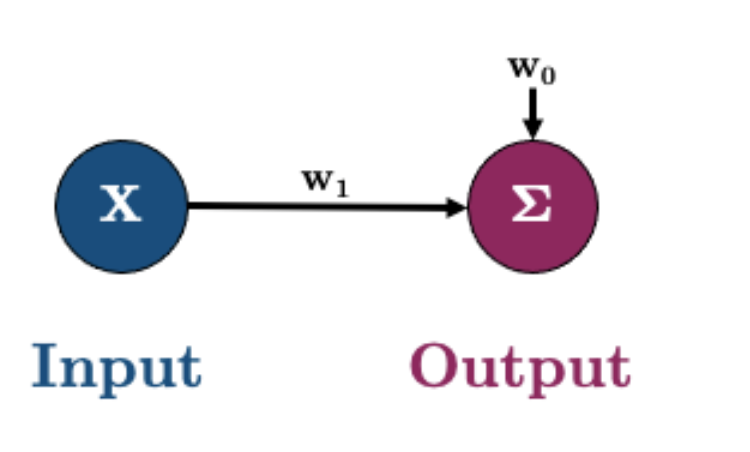

- So let's implement the above in PyTorch to start gaining an intuition about neural networks

- Every neural network model you build in PyTorch has to inherit from `torch.nn.Module`

- Inheritance allows us to inherit commonly needed functionality without having to write code ourselves

- Think about sklearn models: they all inherit common methods like `.fit()`, `.predict()`, `.score()`, etc. When creating a neural network, we define our own architecture but still want common functionality which we inherit from `torch.nn.Module`.

- Let's create a model called `linearRegression` and then we'll talk you through the syntax:

In [ ]:
class linearRegression(nn.Module):  # our class inherits from nn.Module and we can call it anything we like

    def __init__(self, input_size, output_size):
        super().__init__()  # super().__init__() makes our class inherit everything from torch.nn.Module

        self.linear = nn.Linear(input_size, output_size,)  # this is a simple linear layer: wX + b

    def forward(self, x):
        out = self.linear(x)
        return out

Let's step through the above:

```python
class linearRegression(nn.Module):
    
    def __init__(self, input_size, output_size):
        super().__init__()
```

Here we're creating a class called `linearRegression` and inheriting the methods and attributes of `nn.Module`

(hint: try typing `help(linearRegression)` to see all the things we inherited from `nn.Module`).

```python
        self.linear = nn.Linear(input_size, output_size)
```

Here we're defining a "Linear" layer, which just means `wX + b`, i.e., the weights of the network, multiplied by the inputs plus the bias.

```python
    def forward(self, x):
        out = self.linear(x)
        return out
```

PyTorch networks created with `nn.Module` must have a `forward()` method. It accepts the input data `x` and passes it through the defined operations. In this case, we are passing `x` into our linear layer and getting an output `out`.

- After defining the model class, we can create an instance of that class:

In [ ]:
model = linearRegression(input_size=1, output_size=1)

- We can check out our model using `print()`:

In [ ]:
print(model)

linearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


- Or the more useful `summary()` (which we imported at the top of this notebook with `from torchsummary import summary`):

In [ ]:
summary(model, (1,));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]               2
Total params: 2
Trainable params: 2
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


- Notice how we have two parameters? We have one for the weight (`w1`) and one for the bias (`w0`)

- These were initialized **randomly** by PyTorch when we created our model. They can be accessed with `model.state_dict()`:

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.1233]])),
             ('linear.bias', tensor([-0.5044]))])

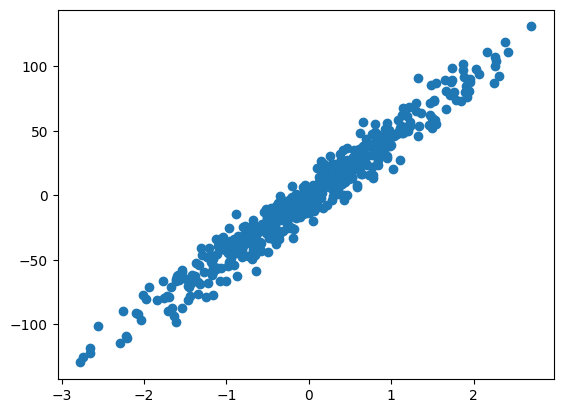

In [ ]:
import matplotlib.pyplot as plt

X, y = make_regression(n_samples=500, n_features=1, random_state=0, noise=10.0)
plt.scatter(X,y)

- Our `x` and `y` data are currently Numpy arrays but they need to be PyTorch tensors
- Let's convert them:

In [ ]:
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

- We have a working model right now and could tell it to give us some output with this syntax:

In [ ]:
model(X_t[0])

tensor([-0.5809], grad_fn=<ViewBackward0>)

That's just a raw prediction, and far from the actual value of:

In [ ]:
y_t[0]

tensor(31.0760)

It's because our model is not trained yet.

What does training mean? In the context of what we've learned so far, it means that we haven't yet done an SGD run to find optimal weights.

- As we learned before, to fit our model we need:

    1. **a loss function** (called "`criterion`" in PyTorch) to tell us how good/bad our predictions are. We'll use mean squared error, `torch.nn.MSELoss()`
    
    2. **an optimization algorithm** to help optimize model parameters. We'll use SGD, `torch.optim.SGD()`

In [ ]:
LEARNING_RATE = 0.02
criterion = nn.MSELoss()  # loss function
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)  # optimization algorithm is SGD

- Before we train we are going to create a **data loader** to help batch the data
- We'll talk more about these next lectures but they are just generators that yield data to us on request
- We'll use a `BATCH_SIZE=50` (which should give us 10 batches because we have 500 data points)

In [ ]:
BATCH_SIZE = 50
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
dataloader

- We should have 10 batches:

In [ ]:
len(dataloader)

10

- We can look at a batch using this syntax:

In [ ]:
XX, yy = next(iter(dataloader))
print(f"Shape of feature data (X) in batch: {XX.shape}")
print(f"Shape of response data (y) in batch: {yy.shape}")

Shape of feature data (X) in batch: torch.Size([50, 1])
Shape of response data (y) in batch: torch.Size([50])


Let's write code for doing a typical SGD with 10 epochs, but using automatic differentiation of PyTorch:

In [ ]:
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""

    for epoch in range(epochs):
        losses = 0

        for X, y in dataloader:

            optimizer.zero_grad()       # Clear gradients w.r.t. parameters
            y_hat = model(X).flatten()  # Forward pass to get output
            loss = criterion(y_hat, y)  # Calculate loss
            loss.backward()             # Getting gradients w.r.t. parameters
            optimizer.step()            # Update parameters
            losses += loss.item()       # Add loss for this batch to running total

        if verbose: print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")

Before starting the training, here are the model parameters before training for reference:

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.1233]])),
             ('linear.bias', tensor([-0.5044]))])

In [ ]:
trainer(model, criterion, optimizer, dataloader, epochs=100, verbose=True)

epoch: 1, loss: 1573.3701
epoch: 2, loss: 749.2626
epoch: 3, loss: 384.2852
epoch: 4, loss: 222.2032
epoch: 5, loss: 150.3209
epoch: 6, loss: 118.5576
epoch: 7, loss: 104.4323
epoch: 8, loss: 98.1394
epoch: 9, loss: 95.3850
epoch: 10, loss: 94.1946
epoch: 11, loss: 93.5934
epoch: 12, loss: 93.3696
epoch: 13, loss: 93.2843
epoch: 14, loss: 93.2776
epoch: 15, loss: 93.1891
epoch: 16, loss: 93.2952
epoch: 17, loss: 93.2270
epoch: 18, loss: 93.1790
epoch: 19, loss: 93.2033
epoch: 20, loss: 93.1805
epoch: 21, loss: 93.1956
epoch: 22, loss: 93.2617
epoch: 23, loss: 93.1650
epoch: 24, loss: 93.3483
epoch: 25, loss: 93.2069
epoch: 26, loss: 93.2127
epoch: 27, loss: 93.1748
epoch: 28, loss: 93.2226
epoch: 29, loss: 93.2610
epoch: 30, loss: 93.1901
epoch: 31, loss: 93.1886
epoch: 32, loss: 93.1778
epoch: 33, loss: 93.2434
epoch: 34, loss: 93.1608
epoch: 35, loss: 93.1851
epoch: 36, loss: 93.1905
epoch: 37, loss: 93.2301
epoch: 38, loss: 93.3029
epoch: 39, loss: 93.2339
epoch: 40, loss: 93.2401
e

- Now our model has been trained, our parameters should be different than before:

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[45.4990]])),
             ('linear.bias', tensor([-0.7223]))])

- We got pretty close to what we would get with `sklearn`
- We could do better by changing the number of epochs or the learning rate

- By the way, check out what happens if we run `trainer()` again:

In [ ]:
trainer(model, criterion, optimizer, dataloader, epochs=20, verbose=True)

epoch: 1, loss: 93.2938
epoch: 2, loss: 93.2786
epoch: 3, loss: 93.2602
epoch: 4, loss: 93.2232
epoch: 5, loss: 93.2429
epoch: 6, loss: 93.1984
epoch: 7, loss: 93.1971
epoch: 8, loss: 93.2154
epoch: 9, loss: 93.2526
epoch: 10, loss: 93.2323
epoch: 11, loss: 93.2353
epoch: 12, loss: 93.2812
epoch: 13, loss: 93.2888
epoch: 14, loss: 93.2521
epoch: 15, loss: 93.1925
epoch: 16, loss: 93.2955
epoch: 17, loss: 93.2338
epoch: 18, loss: 93.2840
epoch: 19, loss: 93.1959
epoch: 20, loss: 93.2260


- **Our model continues where we left off**

- This may or may not be what you want. We can start from scratch by re-making the `model` and `optimizer`.

# REGRESSION NEURAL NETWORKS

### Multiple Linear Regression with a Neural Network

- Now, let's do a multiple linear regression with 3 features


- Let's go ahead and create some data:

In [ ]:
# Create dataset
X, y = make_regression(n_samples=500, n_features=3, random_state=0, noise=10.0)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# Create dataloader
BATCH_SIZE = 50
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

- And let's create the above model:

In [ ]:
class linearRegression(nn.Module):  # our class inherits from nn.Module and we can call it anything we like

    def __init__(self, input_size, output_size):
        super().__init__()  # super().__init__() makes our class inherit everything from torch.nn.Module

        self.linear = nn.Linear(input_size, output_size,)  # this is a simple linear layer: wX + b

    def forward(self, x):
        out = self.linear(x)
        return out

In [ ]:
model = linearRegression(input_size=3, output_size=1)

- We should now have 4 parameters (3 weights and 1 bias)

In [ ]:
summary(model, (3,));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]               4
Total params: 4
Trainable params: 4
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


- Looks good! Let's train the model and then compare it to sklearn's `LinearRegression()`:

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[ 0.3697, -0.1308,  0.3637]])),
             ('linear.bias', tensor([0.0980]))])

In [ ]:
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""

    for epoch in range(epochs):
        losses = 0

        for X, y in dataloader:

            optimizer.zero_grad()       # Clear gradients w.r.t. parameters
            y_hat = model(X).flatten()  # Forward pass to get output
            loss = criterion(y_hat, y)  # Calculate loss
            loss.backward()             # Getting gradients w.r.t. parameters
            optimizer.step()            # Update parameters
            losses += loss.item()       # Add loss for this batch to running total

        if verbose: print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
trainer(model, criterion, optimizer, dataloader, epochs=100, verbose=True)

epoch: 1, loss: 1629.4982
epoch: 2, loss: 274.8711
epoch: 3, loss: 122.8193
epoch: 4, loss: 103.8256
epoch: 5, loss: 101.4933
epoch: 6, loss: 101.3230
epoch: 7, loss: 101.5993
epoch: 8, loss: 101.3648
epoch: 9, loss: 101.4418
epoch: 10, loss: 101.7172
epoch: 11, loss: 101.5124
epoch: 12, loss: 101.4842
epoch: 13, loss: 101.5001
epoch: 14, loss: 101.7121
epoch: 15, loss: 101.5852
epoch: 16, loss: 101.5526
epoch: 17, loss: 101.6301
epoch: 18, loss: 101.2541
epoch: 19, loss: 101.6904
epoch: 20, loss: 101.7435
epoch: 21, loss: 101.6623
epoch: 22, loss: 101.1921
epoch: 23, loss: 101.3725
epoch: 24, loss: 101.4186
epoch: 25, loss: 101.6669
epoch: 26, loss: 101.2547
epoch: 27, loss: 101.4761
epoch: 28, loss: 101.5300
epoch: 29, loss: 101.3944
epoch: 30, loss: 101.3413
epoch: 31, loss: 101.9058
epoch: 32, loss: 101.6211
epoch: 33, loss: 101.3003
epoch: 34, loss: 101.4891
epoch: 35, loss: 101.7169
epoch: 36, loss: 101.3257
epoch: 37, loss: 101.4930
epoch: 38, loss: 101.3465
epoch: 39, loss: 101

In [ ]:
sk_model = LinearRegression().fit(X, y)
pd.DataFrame({"w0": [sk_model.intercept_, model.state_dict()['linear.bias'].item()],
              "w1": [sk_model.coef_[0], model.state_dict()['linear.weight'][0, 0].item()],
              "w2": [sk_model.coef_[1], model.state_dict()['linear.weight'][0, 1].item()],
              "w3": [sk_model.coef_[2], model.state_dict()['linear.weight'][0, 2].item()]},
             index=['sklearn', 'pytorch']).round(2)

,w0,w1,w2,w3
sklearn,0.43,0.62,55.99,11.14
pytorch,0.52,0.70,55.96,11.18


You can with 1000 epochs and then compare!

# Non-linear Regression with a Neural Network

- Okay so we can make a simple network to imitate simple and multiple *linear* regression
- For example, what happens when we have more complicated datasets like this?

First let's create a helper plotting function

In [ ]:
def plot_regression(
    x, y, y_hat=None, x_range=[-3, 3], y_range=[-150, 150], dx=1, dy=30
):
    if x.ndim > 1:
        x = np.squeeze(x)
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(x=x, y=y, mode="markers", marker=dict(size=10), name="data")
    )
    if y_hat is not None:
        if y_hat.ndim > 1:
            y_hat = np.squeeze(y_hat)
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_hat,
                line_color="red",
                mode="lines",
                line=dict(width=3),
                name="Fitted line",
            )
        )
        width = 550
        title_x = 0.46
    else:
        width = 500
        title_x = 0.5
    fig.update_layout(
        width=width,
        height=500,
        # title="Pokemon stats",
        title_x=title_x,
        title_y=0.93,
        xaxis_title="x",
        yaxis_title="y",
        margin=dict(t=60),
    )
    fig.update_xaxes(range=x_range, tick0=x_range[0], dtick=dx)
    fig.update_yaxes(range=y_range, tick0=y_range[0], dtick=dy)
    return fig

In [ ]:
# Create dataset
np.random.seed(2020)

X = np.sort(np.random.randn(500))
y = X ** 2 + 15 * np.sin(X) **3

X_t = torch.tensor(X[:, None], dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# Create dataloader
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

plot_regression(X, y, y_range=[-25, 25], dy=5)

- This is obviously non-linear, and we need to introduce some **non-linearities** into our network
- Remember that these non-linearities are what make neural networks so powerful and they are called **"activation functions"**
- We are going to create a new model class that includes a non-linearity, that is, a sigmoid function:

$$S(x)=\frac{1}{1+e^{-x}}$$

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

xs = np.linspace(-15, 15, 100)
plot_regression(xs, [0], sigmoid(xs), x_range=[-5, 5], y_range=[0, 1], dy=0.2)

- All this means is that the value of each node in the hidden layer will be transformed by the activation function, thus introducing non-linear elements to our model
- There's **two main ways** of creating the above model in PyTorch, we'll show you both:

In [ ]:
class nonlinRegression(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)       # input -> hidden layer
        x = self.sigmoid(x)      # sigmoid activation function in hidden layer
        x = self.output(x)       # hidden -> output layer
        return x

- Note how our `forward()` method now passes `x` through the `nn.Sigmoid()` function after the hidden layer
- The above method is very clear and flexible, but using `nn.Sequential()` is preferred to combine the layers together in the constructor:

In [ ]:
class nonlinRegression(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.main = torch.nn.Sequential(
            nn.Linear(input_size, hidden_size),  # input -> hidden layer
            nn.Sigmoid(),                        # sigmoid activation function in hidden layer
            nn.Linear(hidden_size, output_size)  # hidden -> output layer
        )

    def forward(self, x):
        x = self.main(x)
        return x

- Let's make an instance of our new class and confirm it has 10 parameters (6 weights + 4 biases):

In [ ]:
model = nonlinRegression(1, 3, 1)
summary(model, (1,));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 3]               6
           Sigmoid-2                    [-1, 3]               0
            Linear-3                    [-1, 1]               4
Total params: 10
Trainable params: 10
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


- We can add a bit more complexity to the model by using 10 nodes in the hidden layer
- Note that in this case, nothing changes except the numbers while instatiating a model

In [ ]:
model = nonlinRegression(1, 10, 1)
summary(model, (1,));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]              20
           Sigmoid-2                   [-1, 10]               0
            Linear-3                    [-1, 1]              11
Total params: 31
Trainable params: 31
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


Now, let's train.

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

trainer(model, criterion, optimizer, dataloader, epochs=100, verbose=True)

epoch: 1, loss: 56.6570
epoch: 2, loss: 53.9342
epoch: 3, loss: 50.8404
epoch: 4, loss: 47.2311
epoch: 5, loss: 43.0148
epoch: 6, loss: 38.4696
epoch: 7, loss: 33.6526
epoch: 8, loss: 29.1624
epoch: 9, loss: 25.0955
epoch: 10, loss: 21.5967
epoch: 11, loss: 18.7492
epoch: 12, loss: 16.5139
epoch: 13, loss: 14.7809
epoch: 14, loss: 13.4731
epoch: 15, loss: 12.4964
epoch: 16, loss: 11.7575
epoch: 17, loss: 11.2244
epoch: 18, loss: 10.7981
epoch: 19, loss: 10.4778
epoch: 20, loss: 10.2194
epoch: 21, loss: 10.0200
epoch: 22, loss: 9.8444
epoch: 23, loss: 9.7000
epoch: 24, loss: 9.5691
epoch: 25, loss: 9.4681
epoch: 26, loss: 9.3684
epoch: 27, loss: 9.2901
epoch: 28, loss: 9.2098
epoch: 29, loss: 9.1309
epoch: 30, loss: 9.0573
epoch: 31, loss: 8.9926
epoch: 32, loss: 8.9604
epoch: 33, loss: 8.9019
epoch: 34, loss: 8.8426
epoch: 35, loss: 8.8121
epoch: 36, loss: 8.7762
epoch: 37, loss: 8.7373
epoch: 38, loss: 8.7024
epoch: 39, loss: 8.6817
epoch: 40, loss: 8.6548
epoch: 41, loss: 8.6200
epoc

In [ ]:
y_p = model(X_t).detach().numpy().squeeze()
plot_regression(X, y, y_p, y_range=[-25, 25], dy=5)

- Take a look at those non-linear predictions
- Our model is not great and we could make it better soon by adjusting the learning rate, the number of nodes, and the number of epochs

# Deep Learning

You've probably heard the magic term **"deep learning"** and you're about to find out what it means

- **Deep neural network: a neural network with more than 1 hidden layer**
- On the other hand, a neural network with only 1 hidden layer is called a **shallow neural network**.

I would like you to think of each layer as a "feature engineer", it is trying to extract information from the layer before it

- Let's create a "deep" network of 2 layers:

In [ ]:
class deepRegression(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.Sigmoid(),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.Sigmoid(),
            nn.Linear(hidden_size_2, output_size)
        )

    def forward(self, x):
        out = self.main(x)
        return out

In [ ]:
model = deepRegression(1, 5, 3, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.3)

In [ ]:
trainer(model, criterion, optimizer, dataloader, epochs=10**3, verbose=False)
plot_regression(X, y, model(X_t).detach(), y_range=[-25, 25], dy=5)

The neural network is doing a good job, but it's still struggling to handle data points near the boundaries, but we can do better by having more neurons in our network:

In [ ]:
model = deepRegression(1, 10, 10, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

In [ ]:
trainer(model, criterion, optimizer, dataloader, epochs=10**3, verbose=False)
plot_regression(X, y, model(X_t).detach(), y_range=[-25, 25], dy=5)

# Classification Neural Networks

### Binary Classification

- Up until now, we've been looking at developing networks for regression tasks, but what if we want to do binary classification?
- Well, what can we do in Logistic Regression? We can just pass the output of a regression into the Sigmoid Function to get a value between 0 and 1 (a probability of an observation belonging to the positive class). Let's do the same thing here
- Let's create a toy dataset first:

In [ ]:
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=2020)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

In [ ]:
LEARNING_RATE = 0.1
BATCH_SIZE = 50

# Create dataloader
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

- We're going to start using `ReLU` as our activation function(s) and `Adam` as our optimizer because these are what are currently, commonly used in practice.
- We are doing classification now so we'll need to use log loss (binary cross entropy) as our loss function:
$$L(w) = \sum_{x,y \in D} -y \log(\hat{y}) - (1-y)\log(1-\hat{y})$$
- In PyTorch, binary cross entropy loss criterion is `torch.nn.BCELoss`
- The formula expects a "probability" which is why we add a Sigmoid function to the end of out network.

In [ ]:
class binaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()  # <-- this will squash our output to a probability between 0 and 1
        )

    def forward(self, x):
        out = self.main(x)
        return out

- **But wait!**

- While we can do the above and then train with a `torch.nn.BCELoss` loss function, there's a better way
- We can omit the Sigmoid function and just use `torch.nn.BCEWithLogitsLoss` (which combines a Sigmoid layer and the BCELoss)
- Why would we do this? It's numerically more stable. We use it here for stability)
- From the docs:
>"*This version is more numerically stable than using a plain Sigmoid followed by a BCELoss as, by combining the operations into one layer, we take advantage of the log-sum-exp trick for numerical stability.*"
- So actually, here's our model (no Sigmoid layer at the end because it's included in the loss function we'll use):

In [ ]:
class binaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        out = self.main(x)
        return out

- Let's train the model:

In [ ]:
model = binaryClassifier(2, 5, 1)
criterion = torch.nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  # optimization algorithm
trainer(model, criterion, optimizer, dataloader, epochs=20, verbose=True)

epoch: 1, loss: 0.6783
epoch: 2, loss: 0.6179
epoch: 3, loss: 0.5306
epoch: 4, loss: 0.4238
epoch: 5, loss: 0.3157
epoch: 6, loss: 0.2287
epoch: 7, loss: 0.1673
epoch: 8, loss: 0.1310
epoch: 9, loss: 0.1093
epoch: 10, loss: 0.0943
epoch: 11, loss: 0.0852
epoch: 12, loss: 0.0756
epoch: 13, loss: 0.0687
epoch: 14, loss: 0.0584
epoch: 15, loss: 0.0511
epoch: 16, loss: 0.0454
epoch: 17, loss: 0.0409
epoch: 18, loss: 0.0408
epoch: 19, loss: 0.0375
epoch: 20, loss: 0.0373


- To be clear, our model is just outputting **logits**, which are some number between -∞ and +∞ (we aren't applying Sigmoid), so:
    - To get the probabilities we would need to pass them through a Sigmoid;
    - To get classes, we can apply some threshold (usually 0.5)
- For example, we would expect the point `(0, 0)` to have a high probability and the point `(-1,-1)` to have a low probability:

In [ ]:
prediction = model(torch.tensor([[0, 0], [-1, -1]], dtype=torch.float32)).detach()
print(prediction)

tensor([[ 15.5071],
        [-11.8612]])


In [ ]:
probability = nn.Sigmoid()(prediction)
print(probability)

tensor([[1.0000e+00],
        [7.0590e-06]])


In [ ]:
classes = np.where(probability > 0.5, 1, 0)
print(classes)

[[1]
 [0]]


### Multiclass Classification

- For multiclass classification, we can use softmax
$$\sigma(\vec{z})_i=\frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}$$
- It basically makes sure all the outputs are probabilities between 0 and 1, and that they all sum to 1.
- `torch.nn.CrossEntropyLoss` is a loss that combines a Softmax with cross entropy loss.
- Let's try a 4-class classification problem using the following network:
<img src="img/nn-8.png" width=700>

In [ ]:
class multiClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.main = torch.nn.Sequential(
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        out = self.main(x)
        return out

In [ ]:
X, y = make_blobs(n_samples=200, centers=4, center_box=(-1.2, 1.2), cluster_std=[0.15, 0.15, 0.15, 0.15], random_state=12345)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.int64)

# Create dataloader
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

- Let's train this model

In [ ]:
model = multiClassifier(2, 5, 4)
criterion = torch.nn.CrossEntropyLoss() # loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.2)  # optimization algorithm

for epoch in range(10):
    losses = 0
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()       # Clear gradients w.r.t. parameters
        y_hat = model(X_batch)            # Forward pass to get output
        loss = criterion(y_hat, y_batch)  # Calculate loss
        loss.backward()             # Getting gradients w.r.t. parameters
        optimizer.step()            # Update parameters
        losses += loss.item()       # Add loss for this batch to running total
    print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")

epoch: 1, loss: 1.0055
epoch: 2, loss: 0.2694
epoch: 3, loss: 0.0479
epoch: 4, loss: 0.0159
epoch: 5, loss: 0.0063
epoch: 6, loss: 0.0020
epoch: 7, loss: 0.0017
epoch: 8, loss: 0.0008
epoch: 9, loss: 0.0005
epoch: 10, loss: 0.0004


- To be clear once again, our model is just outputting logits, which are some numbers between -∞ and +∞, so:
    - To get the probabilities we would need to pass them to a Softmax;
    - To get classes, we need to select the largest probability.   
- For example, we would expect the point (-1, -1) to have a high probability of belonging to class 1, and the point (0,0) to have the highest probability of belonging to class 2.

In [ ]:
prediction = model(torch.tensor([[-1, -1], [0, 0]], dtype=torch.float32)).detach()
print(prediction)

tensor([[ -9.9235,  23.3313,   5.6871, -47.1926],
        [-11.5756,  -2.1346,   7.6227, -13.1605]])


- Note how we get 4 predictions per data point (a prediction for each of the 4 classes)

In [ ]:
probability = nn.Softmax(dim=1)(prediction)
print(probability)

tensor([[3.6112e-15, 1.0000e+00, 2.1738e-08, 2.3545e-31],
        [4.5947e-09, 5.7871e-05, 9.9994e-01, 9.4183e-10]])


- The predictions should now sum to 1:

In [ ]:
probability.sum(dim=1, keepdim=True)

tensor([[1.0000],
        [1.0000]])

- We can get the class with maximum probability using `argmax()`:

In [ ]:
classes = probability.argmax(dim=1)
print(classes)

tensor([1, 2])


## Convolutional Neural Networks (CNNs)
CNNs are designed to process grid-like data, such as images, using convolutional layers.
The key feature of a CNN is its use of kernels (also called filters) which slide over the input to extract features.
In this section, we will define a simple CNN with different kernel sizes, strides, and padding to observe their effects.

- CNNModel defines a simple CNN with one convolutional layer and max pooling.
- The kernel size, stride, and padding are adjustable, and the fully connected layer is dynamically initialized.
- We pass a random image through the model and visualize the feature maps (outputs of the convolutional layer) to observe the effect of different kernel configurations.

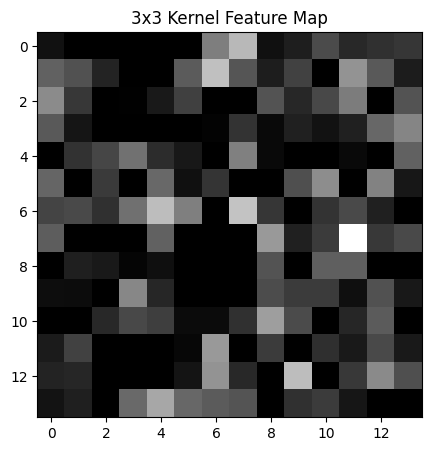

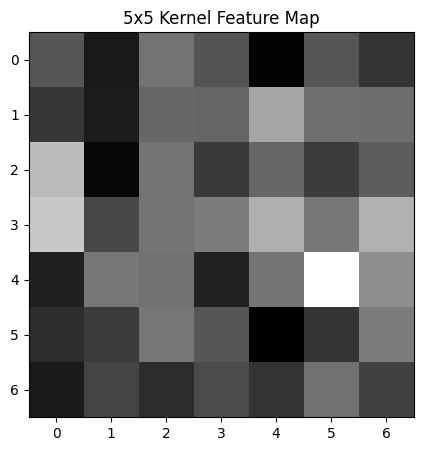

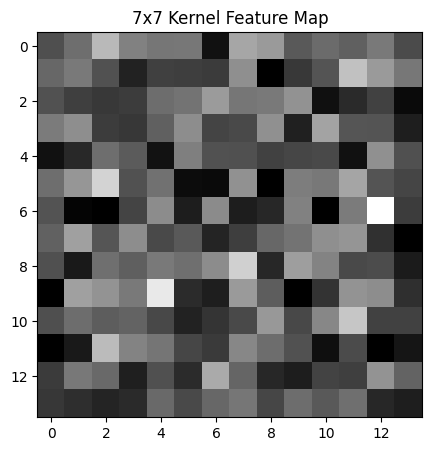

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, kernel_size, stride, padding):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=kernel_size, stride=stride, padding=padding)
        self.pool = nn.MaxPool2d(2, 2)  # 2x2 pooling
        self.fc1 = None  # We'll define this later dynamically based on input size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        # Dynamically calculate the flattened size for the fully connected layer
        flatten_size = x.size(1) * x.size(2) * x.size(3)
        if self.fc1 is None:
            self.fc1 = nn.Linear(flatten_size, 10)  # Initialize FC layer with correct size

        feature_maps = x.clone()  # Store feature maps before flattening
        x = x.view(-1, flatten_size)  # Flatten the pooled feature map
        x = self.fc1(x)  # Fully connected layer
        return x, feature_maps  # Return both the final output and feature maps

# Initialize models with different kernels, strides, and padding
model_3x3 = CNNModel(kernel_size=3, stride=1, padding=1)
model_5x5 = CNNModel(kernel_size=5, stride=2, padding=2)
model_7x7 = CNNModel(kernel_size=7, stride=1, padding=3)

# Sample input (random 28x28 image)
input_image = torch.randn(1, 1, 28, 28)

# Pass the input through the models and get feature maps
output_3x3, feature_maps_3x3 = model_3x3(input_image)
output_5x5, feature_maps_5x5 = model_5x5(input_image)
output_7x7, feature_maps_7x7 = model_7x7(input_image)

# Visualize the feature maps (not the fully connected output)
def visualize_feature_maps(feature_maps, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(feature_maps.detach().numpy().squeeze(), cmap='gray')
    plt.title(title)
    plt.show()

# Visualize the feature maps from the convolutional layers
visualize_feature_maps(feature_maps_3x3, '3x3 Kernel Feature Map')
visualize_feature_maps(feature_maps_5x5, '5x5 Kernel Feature Map')
visualize_feature_maps(feature_maps_7x7, '7x7 Kernel Feature Map')


- Feature Maps: We're now visualizing the intermediate feature maps produced by the convolutional layers (before pooling and flattening).
- Output: The final output from the fully connected layer isn't suitable for image visualization, so we skip visualizing that.

## Convolution and Filters

- Convolution really just means "to pass over the data"
- What are we "passing" over the data? Our filters, which are also called **kernels**
- So how does this help us extract structure from the data?
- Let's see some examples:

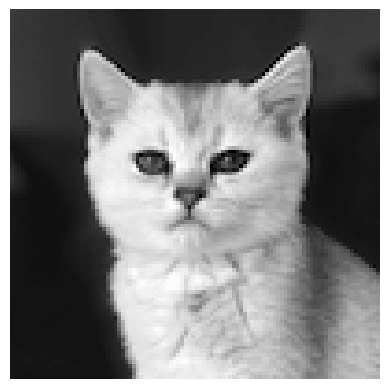

In [ ]:
image = torch.from_numpy(plt.imread("/content/cat.png"))[:, :, 0]
plt.imshow(image, cmap='gray')
plt.axis('off');

- We can blur this image by applying a filter with the following weights:

$$\begin{bmatrix} 0.0625 & 0.125 & 0.0625 \\ 0.125 & 0.25 & 0.125 \\ 0.0625 & 0.125 & 0.0625 \end{bmatrix}$$

In [ ]:
kernel = torch.tensor([[[[ 0.0625,  0.1250,  0.0625],
                         [ 0.1250,  0.2500,  0.1250],
                         [ 0.0625,  0.1250,  0.0625]]]])

In [ ]:
# helper functions alert, do not worry about this!

def plot_conv(image, filter):
    """Plot convs with matplotlib."""
    d = filter.shape[-1]
    conv = torch.nn.Conv2d(1, 1, kernel_size=(d, d), padding=1)
    conv.weight.detach_()
    conv.weight[:] = filter
    fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)
    ax1.imshow(image, cmap='gray')
    ax1.axis('off')
    ax1.set_title("Original")
    ax2.imshow(conv(image[None, None, :]).detach().squeeze(), cmap='gray')
    ax2.set_title("Filtered")
    ax2.axis('off')
    plt.tight_layout();

def plot_convs(image, conv_layer, axis=False):
    """Plot convs with matplotlib. Sorry for this lazy code :D"""
    filtered_image = conv_layer(image[None, None, :])
    n = filtered_image.shape[1]
    if n == 1:
        fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)
        ax1.imshow(image, cmap='gray')
        ax1.set_title("Original")
        ax2.imshow(filtered_image.detach().squeeze(), cmap='gray')
        ax2.set_title("Filter 1")
        ax1.grid(False)
        ax2.grid(False)
        if not axis:
            ax1.axis(False)
            ax2.axis(False)
        plt.tight_layout();
    elif n == 2:
        filtered_image_1 = filtered_image[:,0,:,:]
        filtered_image_2 = filtered_image[:,1,:,:]
        fig, (ax1, ax2, ax3) = plt.subplots(figsize=(10, 4), ncols=3)
        ax1.imshow(image, cmap='gray')
        ax1.set_title("Original")
        ax2.imshow(filtered_image_1.detach().squeeze(), cmap='gray')
        ax2.set_title("Filter 1")
        ax3.imshow(filtered_image_2.detach().squeeze(), cmap='gray')
        ax3.set_title("Filter 2")
        ax1.grid(False)
        ax2.grid(False)
        ax3.grid(False)
        if not axis:
            ax1.axis(False)
            ax2.axis(False)
            ax3.axis(False)
        plt.tight_layout();
    elif n == 3:
        filtered_image_1 = filtered_image[:,0,:,:]
        filtered_image_2 = filtered_image[:,1,:,:]
        filtered_image_3 = filtered_image[:,2,:,:]
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(12, 4), ncols=4)
        ax1.imshow(image, cmap='gray')
        ax1.set_title("Original")
        ax2.imshow(filtered_image_1.detach().squeeze(), cmap='gray')
        ax2.set_title("Filter 1")
        ax3.imshow(filtered_image_2.detach().squeeze(), cmap='gray')
        ax3.set_title("Filter 2")
        ax4.imshow(filtered_image_3.detach().squeeze(), cmap='gray')
        ax4.set_title("Filter 3")
        ax1.grid(False)
        ax2.grid(False)
        ax3.grid(False)
        ax4.grid(False)
        if not axis:
            ax1.axis(False)
            ax2.axis(False)
            ax3.axis(False)
            ax4.axis(False)
        plt.tight_layout();

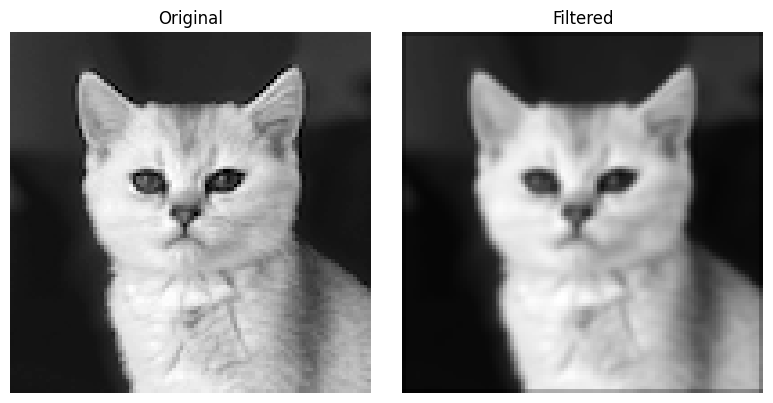

In [ ]:
plot_conv(image, kernel)

- How about this one:

$$\begin{bmatrix} -2 & -1 & 0 \\ -1 & 1 & 1 \\ 0 & 1 & 2 \end{bmatrix}$$

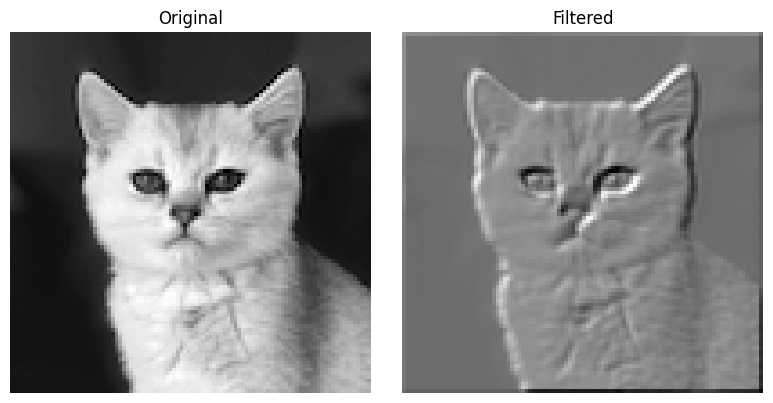

In [ ]:
kernel = torch.tensor([[[[ -2,  -1,  0],
                         [ -1,   1,  1],
                         [  0,   1,  2]]]])
plot_conv(image, kernel)

- One more:

$$\begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix}$$

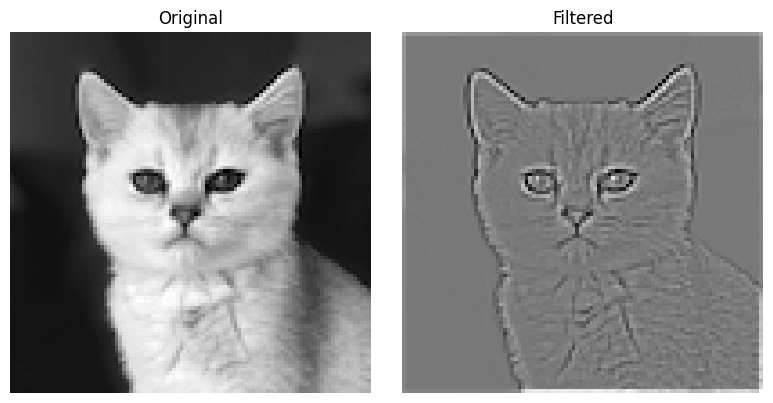

In [ ]:
kernel = torch.tensor([[[[  -1,  -1,   -1],
                         [  -1,   8,   -1],
                         [  -1,  -1,   -1]]]])
plot_conv(image, kernel)

- Be default, our kernels are only applied where the filter fully fits on top of the input
- But we can control this behaviour and the size of our output with:
    - `padding`: "pads" the outside of the input with 0's to allow the kernel to reach the boundary pixels  
    - `strides`: controls how far the kernel "steps" over pixels.

## Coding CNN for the Cat example

### 1. Convolutional Layer

- We saw some example kernels above
- In CNNs the actual values in **the kernel values are the weights your network will learn during training**: your network will learn what structures are important for prediction


- In PyTorch, convolutional layers are defined as `torch.nn.Conv2d`, there are 5 important arguments we need to know:
    1. `in_channels`: how many features are we passing in. Our features are our colour channels: in greyscale, we have 1 feature, in colour, we have 3 channels.    
    2. `out_channels`: how many kernels do we want to use. Analogous to the number of hidden nodes in a hidden layer of a fully connected network.
    3. `kernel_size`: the size of the kernel. Above we were using 3x3. Common sizes are 3x3, 5x5, 7x7.
    4. `stride`: the "step-size" of the kernel.
    5. `padding`: the number of pixels we should pad to the outside of the image so we can get edge pixels.

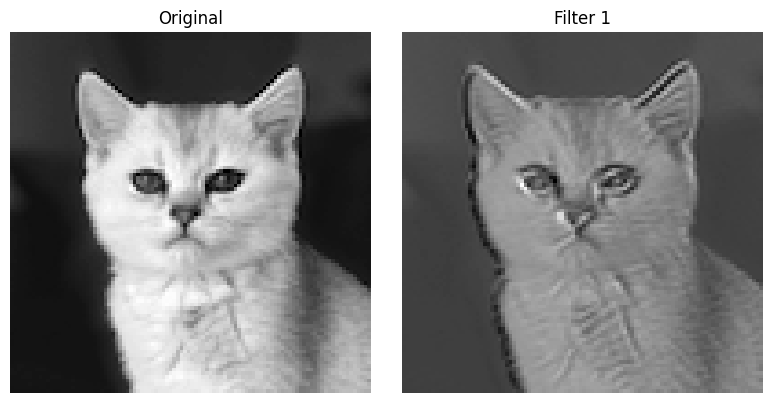

In [ ]:
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=(3, 3))
plot_convs(image, conv_layer)

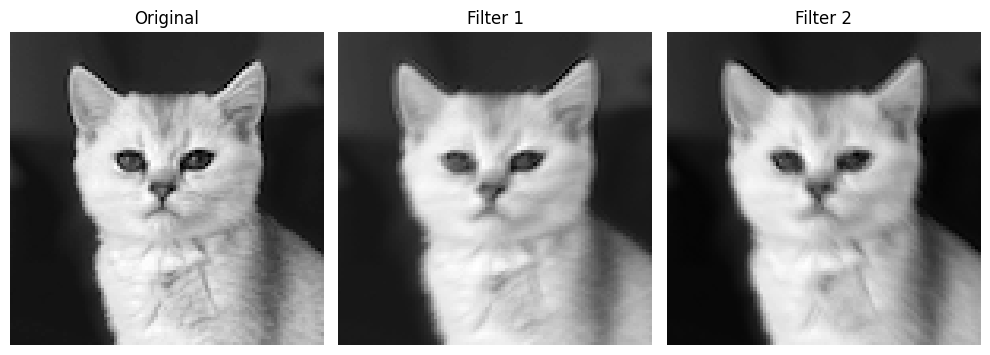

In [ ]:
conv_layer = torch.nn.Conv2d(1, 2, kernel_size=(3, 3))
plot_convs(image, conv_layer)

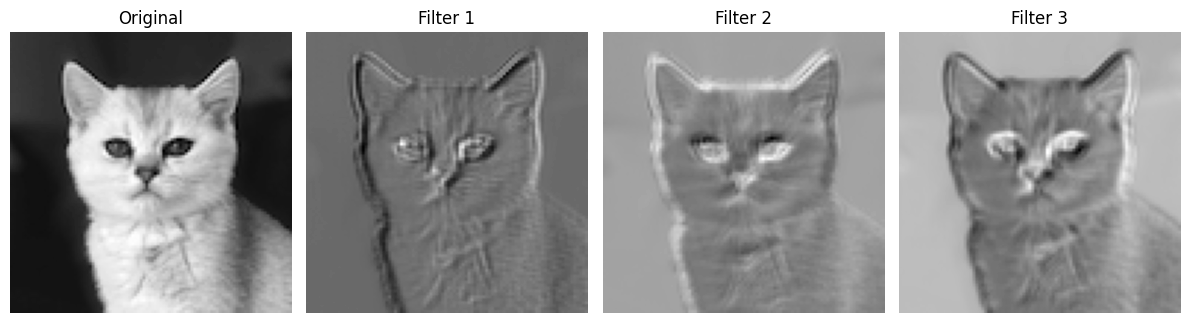

In [ ]:
conv_layer = torch.nn.Conv2d(1, 3, kernel_size=(5, 5))
plot_convs(image, conv_layer)

- If we use a kernel with no padding, our output image will be smaller as we noted earlier
- Let's demonstrate that by using a larger kernel now:

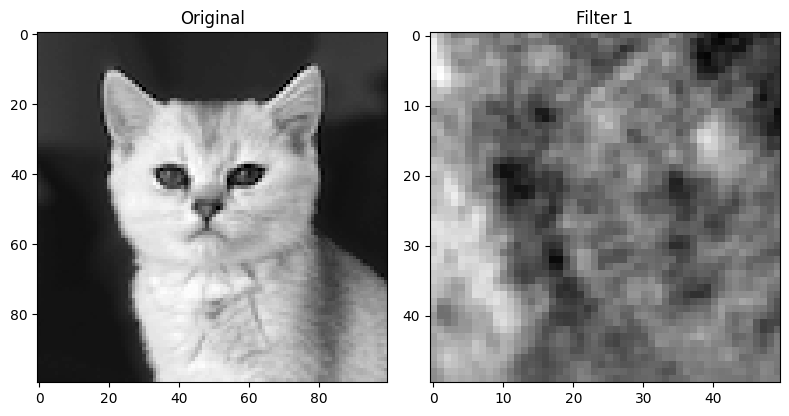

In [ ]:
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=(51, 51))
plot_convs(image, conv_layer, axis=True)

- As we saw, we can add `padding` to the outside of the image to avoid this:

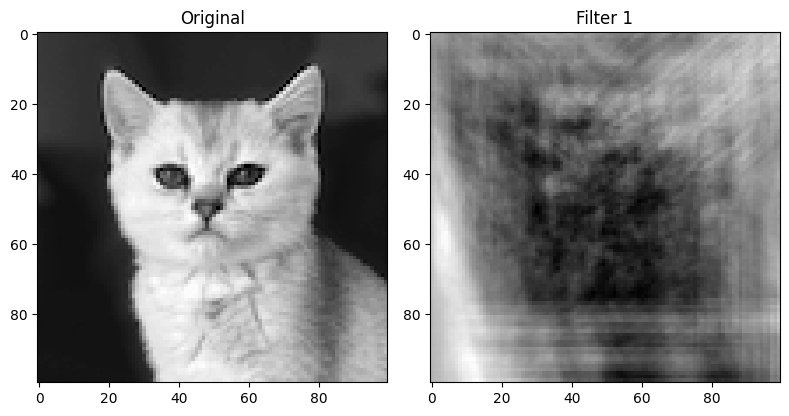

In [ ]:
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=(51, 51), padding=25)
plot_convs(image, conv_layer, axis=True)

> Setting `padding = kernel_size // 2` will always generate an output of the same shape as the input.

- Finally, we also saw before how `strides` influence the size of the output:

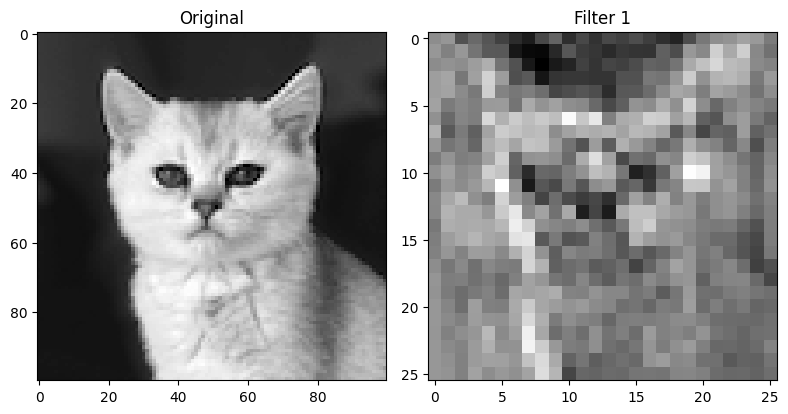

In [ ]:
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=(25, 25), stride=3)
plot_convs(image, conv_layer, axis=True)

- With CNNs, we are no longer flattening our data, so what are our "features"?
- Our features are called **channels** in CNN lingo: they are like the colour channels in an image:
    - A grey-scale image has 1 input feature/channel
    - A coloured image has 3 input features/channel

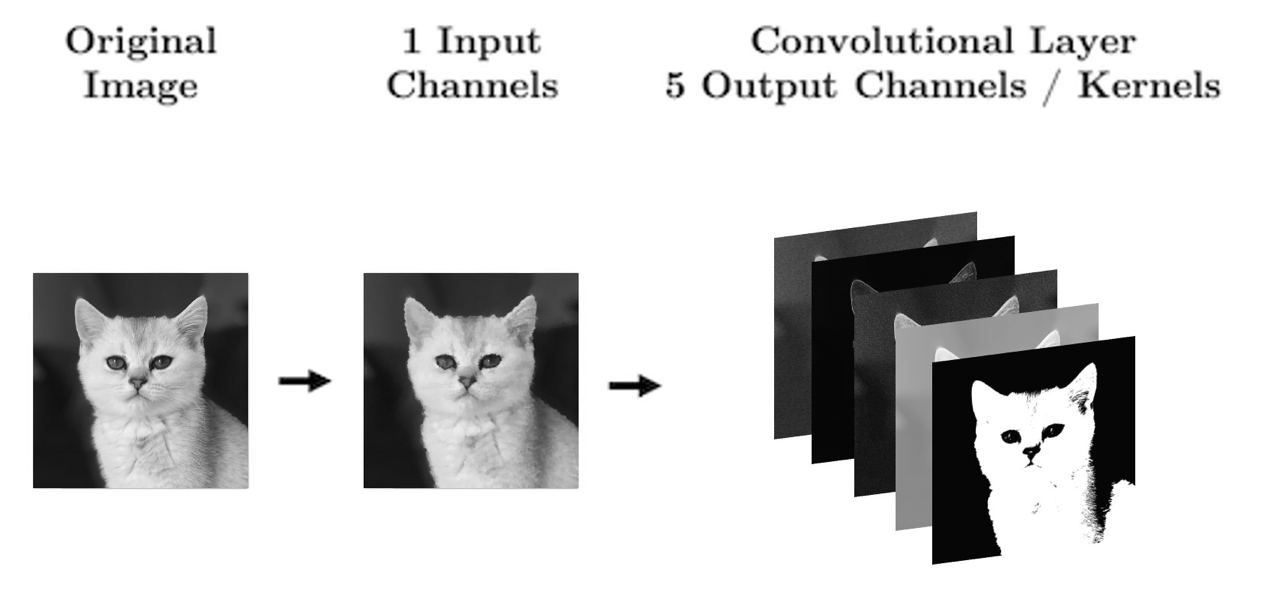

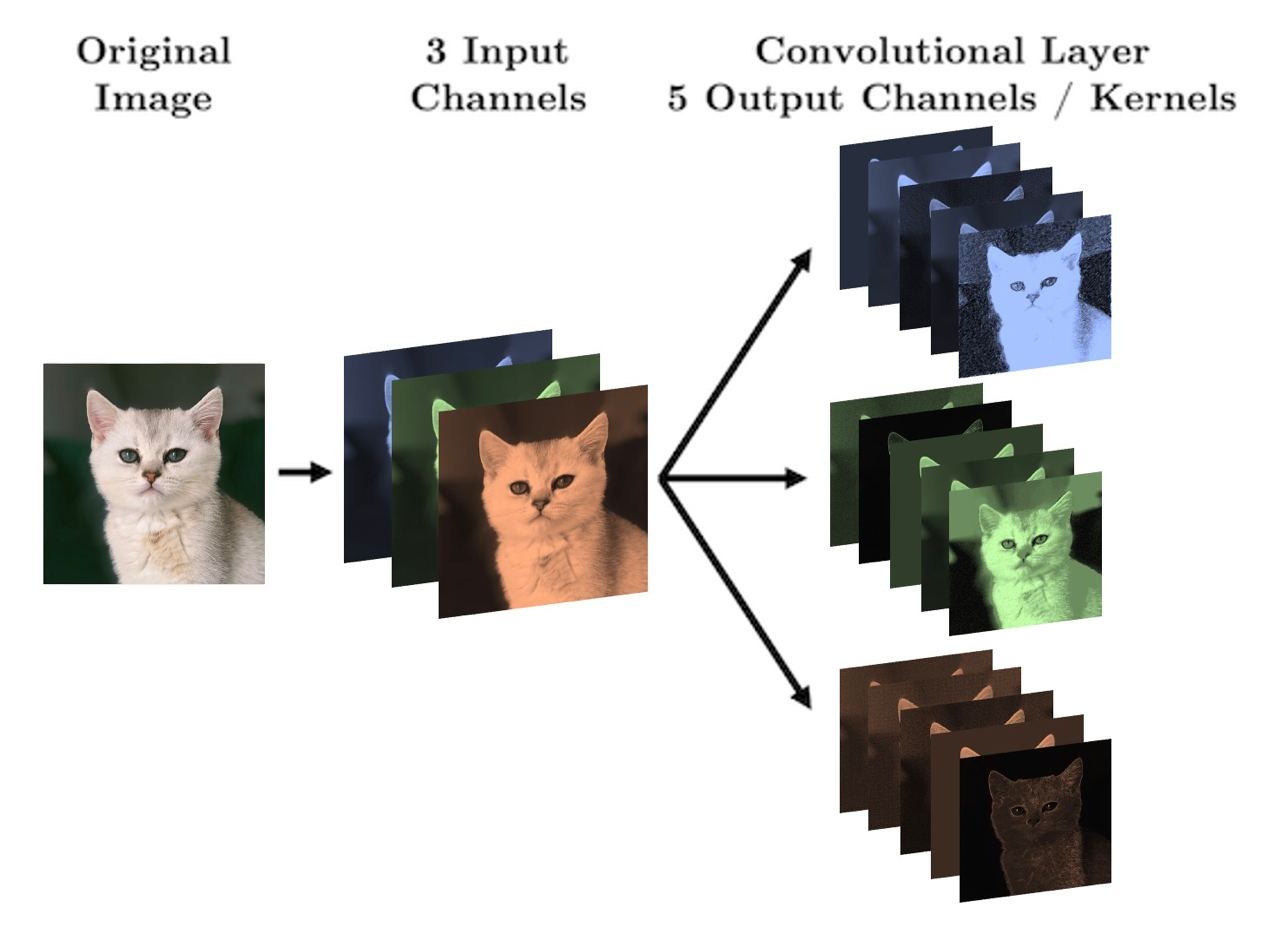

- What's important with CNNs is that the **size of our input data does not impact how many parameters we have in our convolutional layers**. In other words, the structure of the neural network is decoupled from the number of input dimensions
- For example, your kernels don't care how big your image is (i.e., 28 x 28 or 256 x 256), all that matters for the structure of the CNN is:
    1. How many features ("channels") you have: `in_channels`
    2. How many filters you use in each layer: `out_channels`
    3. How big the filters are: `kernel_size`

Let's see some diagrams:
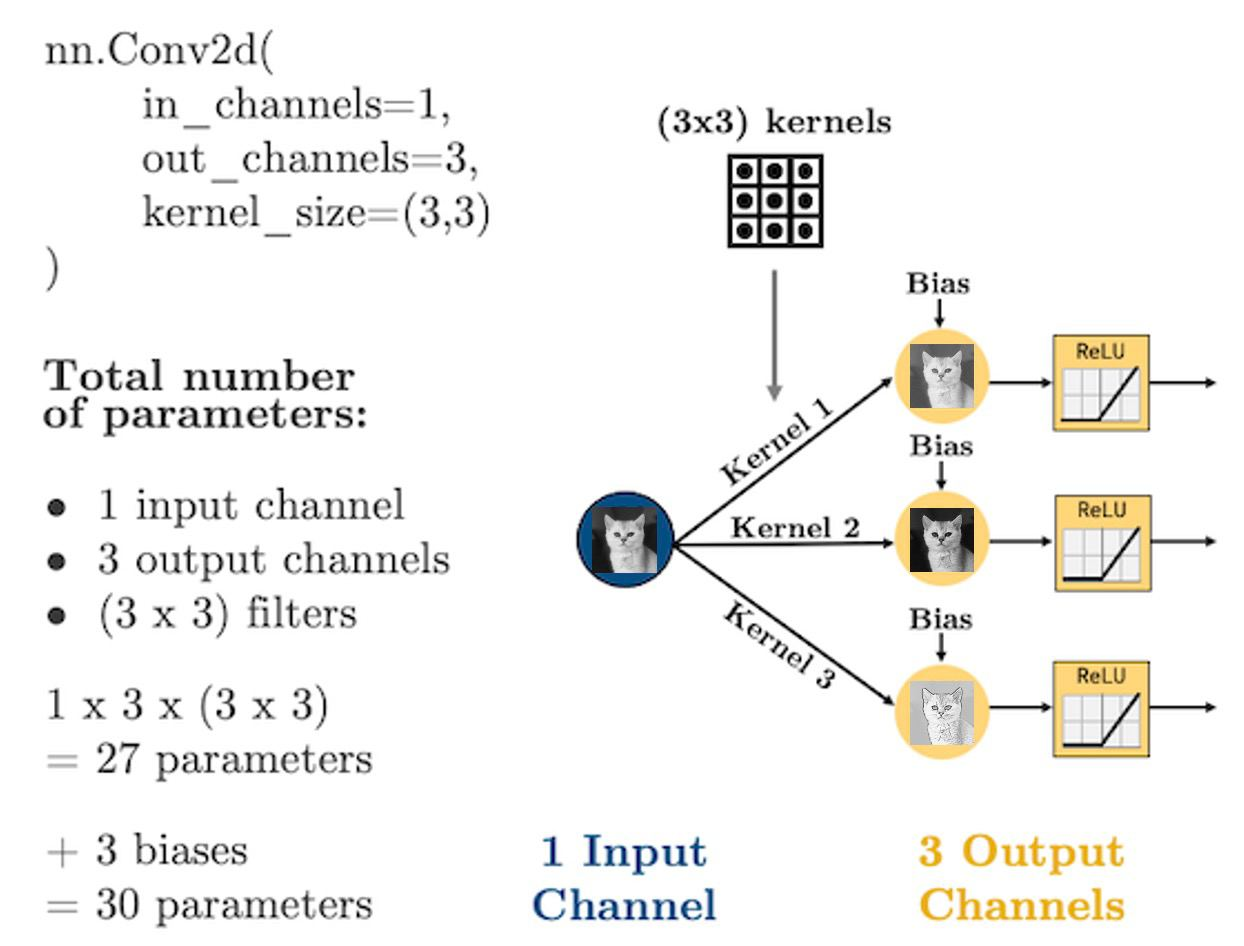

For coloured images (3 channels):

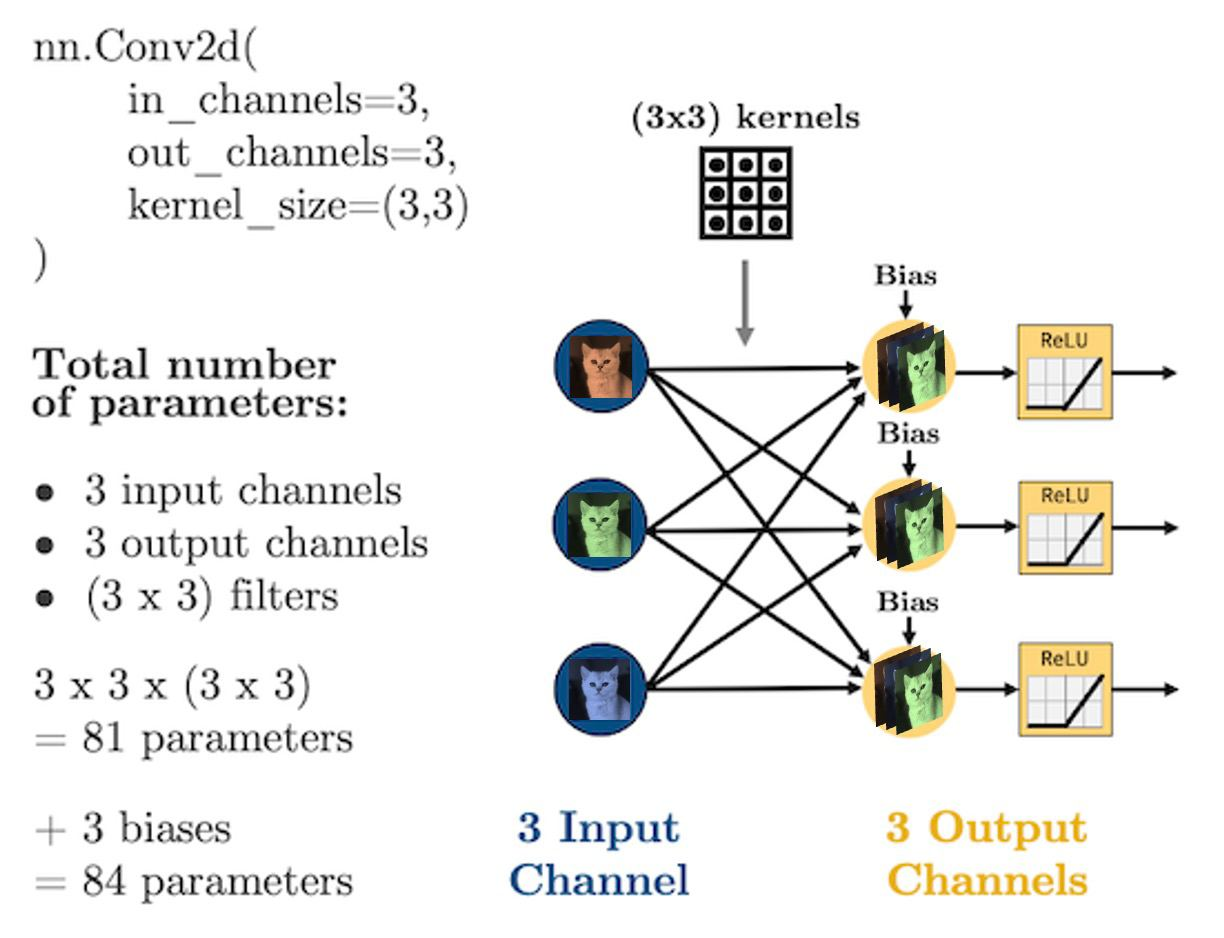

#### Dimensions of Image and Kernel Tensors in PyTorch

**Images**: Regardless of whether we're dealing with input images or a transformed images (the output of a convolution layer), PyTorch stores them in 4-dimensional tensors with the following dimensions:

`(batch_size, n_channels, image_height, image_width)`

<br><br>

**Kernels**: kernels of each convolutional layer are stored as 4-dimensional tensors with these dimensions:

`(n_kernels, n_channels, kernel_height, kernel_width)`
  
> These particular shapes and dimensions are used in order to carry out the matrix operations in the CNN in the most space- and time-efficient way possible.m

Let's look at an example

In [ ]:
image = torch.from_numpy(plt.imread("/content/cat.png"))
image.shape

torch.Size([100, 100, 4])

That's the shape of the image when imported into Numpy and then into PyTorch. The first 3 channels are RGB channels, and sometimes we may also see a 4th channel for opacity of the image (in case of PNG images).

Although there are 3 colour channels, we have already converted this image to grey-scale, so all channels contain the same data (just light intensity).

Now let's take just one of the channels:

In [ ]:
image = image[:, :, 0]
image.shape

torch.Size([100, 100])

OK, let's define a convolution layer, and pass our image to it:

In [ ]:
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=(5, 5))

Now if we run the following cell to pass the image to the conv layer, it will throw an error, because the image does not come in the shape that PyTorch expects it for the conv layer:

In [ ]:
# conv_layer(image)

So we have to reshape the image into `(n_batches, n_channels, image_height, image_width)` first. Since we have just 1 batch of size 1, and 1 channel, we just need to add two extra dimensions:

In [ ]:
image = image[None, None, :]
image.shape

torch.Size([1, 1, 100, 100])

In [ ]:
conv_out = conv_layer(image)
conv_out.shape

torch.Size([1, 1, 96, 96])

It would have also been fine to pass a 3D tensor with dimensions of `(n_channels, image_height, image_width)`. In that case, PyTorch assumes **unbatched** input:

In [ ]:
image = torch.from_numpy(plt.imread("/content/cat.png"))[:, :, 0]
image.shape

torch.Size([100, 100])

In [ ]:
conv_out = conv_layer(image[None, :])
conv_out.shape

torch.Size([1, 96, 96])

If we want to visualize our transformed image, there are two things we need to do first:

- Matplotlib works with Numpy array and doesn't understand PyTorch tensors, so it tries to convert the output of the conv layer to a Numpy array. But for Matplotlib to be able to do that, we first need to **detach** the tensor from PyTorch's computational graph (basically to tell PyTorch that we don't want the computations on this tensor to be tracked), so we have to do `.detach()` on the tensor.

- Matplotlib also only understands 2-dimensional arrays for `plt.imshow()`, so we have to remove the extra dimensions from the output of the conv layer. One way to do it is to use `.squeeze()`, which removes all dimensions of size 1.

In [ ]:
conv_out = conv_layer(image[None, None, :])
conv_out.shape

torch.Size([1, 1, 96, 96])

In [ ]:
conv_out.squeeze().shape

torch.Size([96, 96])

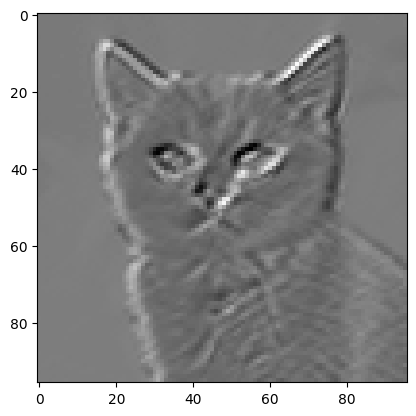

In [ ]:
plt.imshow(conv_layer(image[None, None, :]).detach().squeeze(), cmap='gray');

### 2. Flattening

- With our convolutional layers, we're basically just passing images through the network
- But we're going to eventually want to do some regression or classification
- That means that by the end of our network, we are going to need to `torch.nn.Flatten()` our images:
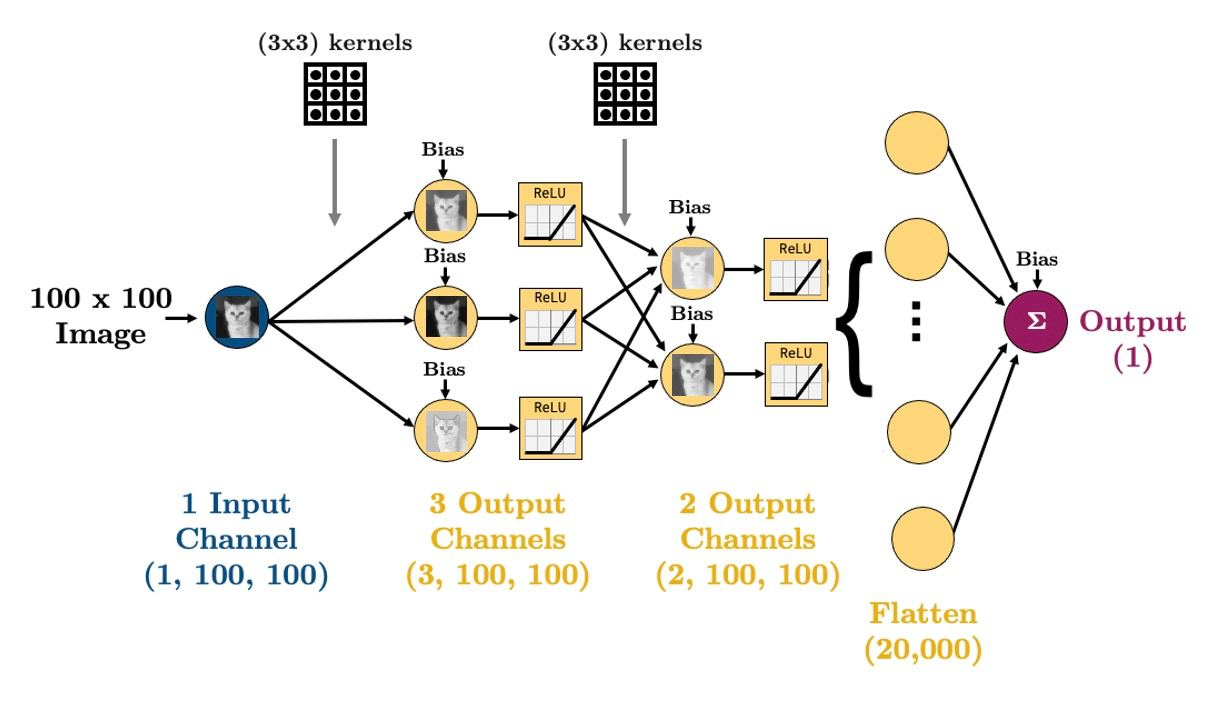

- Let's make that simple CNN above in PyTorch:

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.main = torch.nn.Sequential(

            torch.nn.Conv2d(in_channels=1, out_channels=3, kernel_size=(3, 3), padding=1),
            torch.nn.ReLU(),

            torch.nn.Conv2d(in_channels=3, out_channels=2, kernel_size=(3, 3), padding=1),
            torch.nn.ReLU(),

            torch.nn.Flatten(),
            torch.nn.Linear(20000, 1)
        )

    def forward(self, x):
        out = self.main(x)
        return out

In [ ]:
model = CNN()
summary(model, (1, 100, 100));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 100, 100]              30
              ReLU-2          [-1, 3, 100, 100]               0
            Conv2d-3          [-1, 2, 100, 100]              56
              ReLU-4          [-1, 2, 100, 100]               0
           Flatten-5                [-1, 20000]               0
            Linear-6                    [-1, 1]          20,001
Total params: 20,087
Trainable params: 20,087
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.92
Params size (MB): 0.08
Estimated Total Size (MB): 1.03
----------------------------------------------------------------


- 20,000 parameters in that last layer, that's a lot of parameters
- Is there a way we can reduce this?

### 3. Pooling

- In general, we use **pooling layers** for reducing the dimensionality of the transformed images, such that when we eventually flatten the transformed images (using `torch.nn.Flatten()`), we end up with smaller number of parameters for our CNN.
- It's common practice to do **max pooling** or **average pooling**
- Max pooling seems to work quite well. One explanation for that could be that it derives the sharpest features of a transformed image.
- Here's an example of **max pooling**:
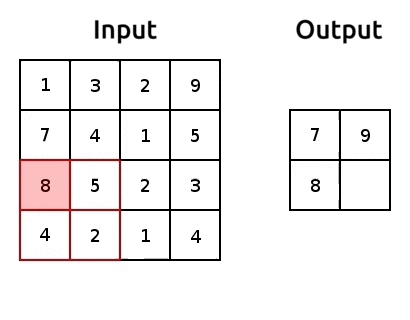

- We can implement pooling with `torch.nn.MaxPool2d()`
- Let's try it out and reduce the number of parameters:

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.main = torch.nn.Sequential(

            torch.nn.Conv2d(in_channels=1, out_channels=3, kernel_size=(3, 3), padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d((2, 2)),

            torch.nn.Conv2d(in_channels=3, out_channels=2, kernel_size=(3, 3), padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d((2, 2)),

            torch.nn.Flatten(),
            torch.nn.Linear(1250, 1)
        )

    def forward(self, x):
        out = self.main(x)
        return out

In [ ]:
model = CNN()
summary(model, (1, 100, 100));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 100, 100]              30
              ReLU-2          [-1, 3, 100, 100]               0
         MaxPool2d-3            [-1, 3, 50, 50]               0
            Conv2d-4            [-1, 2, 50, 50]              56
              ReLU-5            [-1, 2, 50, 50]               0
         MaxPool2d-6            [-1, 2, 25, 25]               0
           Flatten-7                 [-1, 1250]               0
            Linear-8                    [-1, 1]           1,251
Total params: 1,337
Trainable params: 1,337
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.61
Params size (MB): 0.01
Estimated Total Size (MB): 0.65
----------------------------------------------------------------


- We reduced that last layer to 1,251 parameters (~16 times smaller than the original number)